# Analisando o engajamento do Instagram

### O que queremos responder?
- Qual tipo de conteúdo **mais engaja** no Instagram da minha empresa?
<br><br>
- Temos a base de dados do Instagram **desde que o usuário começou a postar na marca até o dia 27/março**
<br><br>
- Ele também dá alguns direcionamentos:
    - Podem ignorar a coluna visualizações, queremos entender apenas curtidas, comentários e interações
    - Tags vazias é que realmente não possuem tag (favor tratar como vazio)

### Vamos importar e visualizar a nossa base

In [1]:
# Importando o pandas
import pandas as pd

In [2]:
# Importar a base em excel
# - Base: 08. Analisando o engajamento no Instagram.xlsx
base = pd.read_csv('instagram.csv')

In [3]:
# Visualizando as 5 primeiras linhas
display(base.head())

,Tipo,Data,Curtidas,Comentários,Visualizações,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,NaN,Loja,N,N,NaN,"2,874"
1,Foto,11-Sep,"2,930",28,NaN,Loja/Produtos,N,N,NaN,"2,958"
2,Foto,11-Sep,"2,807",9,NaN,Loja,N,N,NaN,"2,816"
3,Vídeo,12-Sep,"5,115",49,"82,878",Produtos,N,N,NaN,"5,164"
4,Foto,13-Sep,"4,392",45,NaN,Produtos,S,N,NaN,"4,437"


### Como ele pediu para não considerar a coluna visualizações, vamos retirar essa coluna da base

**O .drop() permite apagar uma coluna ou linha da base:** <br>
base<font color="blue">**.drop(**</font>nome_coluna,axis=1<font color="blue">**)**</font>
- O axis = 1 se refere a coluna, enquanto axis = 0 se refere a linha
- Devemos passar o nome da coluna que queremos apagar da base
- Em caso de mais de 1 coluna, passamos a lista entre colchetes

In [4]:
# Apagando a coluna "Visualizações"
base = base.drop("Visualizações",axis=1)

In [5]:
# Visualizando novamente as 5 primeiras linhas
display(base.head())

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,Loja,N,N,NaN,"2,874"
1,Foto,11-Sep,"2,930",28,Loja/Produtos,N,N,NaN,"2,958"
2,Foto,11-Sep,"2,807",9,Loja,N,N,NaN,"2,816"
3,Vídeo,12-Sep,"5,115",49,Produtos,N,N,NaN,"5,164"
4,Foto,13-Sep,"4,392",45,Produtos,S,N,NaN,"4,437"


In [6]:
# Visualizando as 5 últimas linhas
display(base.tail())

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
47,IGTV,12-Mar,"5,489",77,Dicas de como usar/Novos Produtos,S,N,NaN,"5,566"
48,Foto,20-Mar,"29,084",479,Datas comemorativas/Promoções,S,S,NaN,"29,563"
49,Foto,22-Mar,"9,087",106,NaN,S,S,NaN,"9,193"
50,Foto,26-Mar,"16,551",186,NaN,S,N,NaN,"16,737"
51,IGTV,27-Mar,"4,934",65,Dicas de como usar/Produtos,S,N,NaN,"4,999"


In [7]:
# Tamanho da base
print(base.shape)

(52, 9)


In [8]:
# Se a base for pequena, o display mostra a base completa
display(base)

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,Loja,N,N,NaN,"2,874"
1,Foto,11-Sep,"2,930",28,Loja/Produtos,N,N,NaN,"2,958"
2,Foto,11-Sep,"2,807",9,Loja,N,N,NaN,"2,816"
3,Vídeo,12-Sep,"5,115",49,Produtos,N,N,NaN,"5,164"
4,Foto,13-Sep,"4,392",45,Produtos,S,N,NaN,"4,437"
5,Foto,17-Sep,"5,359",62,Novos Produtos,N,S,S,"5,421"
6,Foto,19-Sep,"21,597",852,Novos Produtos,S,S,NaN,"22,449"
7,Foto,25-Sep,"6,346",33,Produtos,N,S,NaN,"6,379"
8,Foto,27-Sep,"6,355",89,Produtos,S,N,S,"6,444"
9,Vídeo,28-Sep,"4,056",81,Produtos,N,N,NaN,"4,137"


In [9]:
# Verificando as informações
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Tipo         52 non-null     object
 1   Data         52 non-null     object
 2   Curtidas     52 non-null     object
 3   Comentários  52 non-null     int64 
 4   Tags         44 non-null     object
 5   Pessoas      52 non-null     object
 6   Campanhas    52 non-null     object
 7   Carrossel    8 non-null      object
 8   Interacoes   52 non-null     object
dtypes: int64(1), object(8)
memory usage: 3.8+ KB


### Carrossel possui apenas 8 valores não nulos
- Vamos entender os valores de carrossel

In [10]:
# Contando os valores que aparecem na coluna Carrossel
print(base['Carrossel'].value_counts())
display(base[base['Carrossel'].notna()])

Carrossel
S    8
Name: count, dtype: int64


,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
5,Foto,17-Sep,"5,359",62,Novos Produtos,N,S,S,"5,421"
8,Foto,27-Sep,"6,355",89,Produtos,S,N,S,"6,444"
12,Foto,21-Oct,"6,166",55,Novos Produtos,S,S,S,"6,221"
21,Foto,23-Dec,"8,328",93,Produtos,S,N,S,"8,421"
25,Foto,2-Jan,"12,193",138,Novos Produtos,S,N,S,"12,331"
26,Foto,8-Jan,"24,585",354,Datas comemorativas,S,S,S,"24,939"
28,Foto,15-Jan,"9,936",119,Novos Produtos,S,N,S,"10,055"
40,Foto,21-Feb,"21,621",213,Influenciadores,S,S,S,"21,834"


- Na verdade, os valores nulos são de postagens que não são carrossel. Sendo assim o nulo deveria ser "N"

### Tratando os valores nulos

In [11]:
# Filtrando os valores em que carrossel é nulo
filtro = base['Carrossel'].isna()
carrossel_null = base[filtro]
display(carrossel_null)

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,Loja,N,N,NaN,"2,874"
1,Foto,11-Sep,"2,930",28,Loja/Produtos,N,N,NaN,"2,958"
2,Foto,11-Sep,"2,807",9,Loja,N,N,NaN,"2,816"
3,Vídeo,12-Sep,"5,115",49,Produtos,N,N,NaN,"5,164"
4,Foto,13-Sep,"4,392",45,Produtos,S,N,NaN,"4,437"
6,Foto,19-Sep,"21,597",852,Novos Produtos,S,S,NaN,"22,449"
7,Foto,25-Sep,"6,346",33,Produtos,N,S,NaN,"6,379"
9,Vídeo,28-Sep,"4,056",81,Produtos,N,N,NaN,"4,137"
10,Reels,10-Oct,"12,894",249,Trends/Produtos,S,N,NaN,"13,143"
11,Foto,12-Oct,"17,831",391,NaN,S,S,NaN,"18,222"


In [12]:
# Buscando valores que NAO sao nulos
filtro_not_null = base['Carrossel'].notna()
carrossel_not_null = base[filtro_not_null]
display(carrossel_not_null)

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
5,Foto,17-Sep,"5,359",62,Novos Produtos,N,S,S,"5,421"
8,Foto,27-Sep,"6,355",89,Produtos,S,N,S,"6,444"
12,Foto,21-Oct,"6,166",55,Novos Produtos,S,S,S,"6,221"
21,Foto,23-Dec,"8,328",93,Produtos,S,N,S,"8,421"
25,Foto,2-Jan,"12,193",138,Novos Produtos,S,N,S,"12,331"
26,Foto,8-Jan,"24,585",354,Datas comemorativas,S,S,S,"24,939"
28,Foto,15-Jan,"9,936",119,Novos Produtos,S,N,S,"10,055"
40,Foto,21-Feb,"21,621",213,Influenciadores,S,S,S,"21,834"


In [13]:
# Selecionando apenas a coluna Carrossel
display(base['Carrossel'])

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5       S
6     NaN
7     NaN
8       S
9     NaN
10    NaN
11    NaN
12      S
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21      S
22    NaN
23    NaN
24    NaN
25      S
26      S
27    NaN
28      S
29    NaN
30    NaN
31    NaN
32    NaN
33    NaN
34    NaN
35    NaN
36    NaN
37    NaN
38    NaN
39    NaN
40      S
41    NaN
42    NaN
43    NaN
44    NaN
45    NaN
46    NaN
47    NaN
48    NaN
49    NaN
50    NaN
51    NaN
Name: Carrossel, dtype: object

In [14]:
# Agora vamos atribuir o valor N para essa coluna
base.loc[filtro, 'Carrossel'] = 'N'
display(base.head())
print(base.info())

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,Loja,N,N,N,"2,874"
1,Foto,11-Sep,"2,930",28,Loja/Produtos,N,N,N,"2,958"
2,Foto,11-Sep,"2,807",9,Loja,N,N,N,"2,816"
3,Vídeo,12-Sep,"5,115",49,Produtos,N,N,N,"5,164"
4,Foto,13-Sep,"4,392",45,Produtos,S,N,N,"4,437"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Tipo         52 non-null     object
 1   Data         52 non-null     object
 2   Curtidas     52 non-null     object
 3   Comentários  52 non-null     int64 
 4   Tags         44 non-null     object
 5   Pessoas      52 non-null     object
 6   Campanhas    52 non-null     object
 7   Carrossel    52 non-null     object
 8   Interacoes   52 non-null     object
dtypes: int64(1), object(8)
memory usage: 3.8+ KB
None


**Verificando novamente os valores de Carrossel:**

In [15]:
# Verificando novamente os valores dessa coluna
display(base.head())

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
0,Foto,11-Sep,"2,858",16,Loja,N,N,N,"2,874"
1,Foto,11-Sep,"2,930",28,Loja/Produtos,N,N,N,"2,958"
2,Foto,11-Sep,"2,807",9,Loja,N,N,N,"2,816"
3,Vídeo,12-Sep,"5,115",49,Produtos,N,N,N,"5,164"
4,Foto,13-Sep,"4,392",45,Produtos,S,N,N,"4,437"


### Mostrando as informações estatísticas

In [16]:
# Descrição estatística da base
base.rename(columns={'Interacoes ':'Interacoes'}, inplace=True)
for col in ['Curtidas', 'Comentários', 'Interacoes']:
    if col == 'Comentários':
        base[col] = base[col].astype(int)
    else:
        base[col] = base[col].astype(str)
        base[col] = base[col].str.replace(',', '').astype(float)
display(base.describe())

,Curtidas,Comentários,Interacoes
count,52.000000,52.000000,52.000000
mean,12262.730769,189.500000,12452.230769
std,8165.875326,170.687709,8299.390088
min,2807.000000,9.000000,2816.000000
25%,5492.000000,69.500000,5562.500000
50%,9603.000000,128.000000,9773.500000
75%,17621.750000,265.250000,17920.750000
max,37351.000000,852.000000,37853.000000


### Visualizando essas informações de maneira gráfica

In [17]:
dates = base.Data.unique().tolist()
# Number of evenly spaced values you want
n = 8
# Compute step size
step = len(dates) // (n - 1)
# Select evenly spaced values
new_dates = [dates[i] for i in range(0, len(dates), step)]

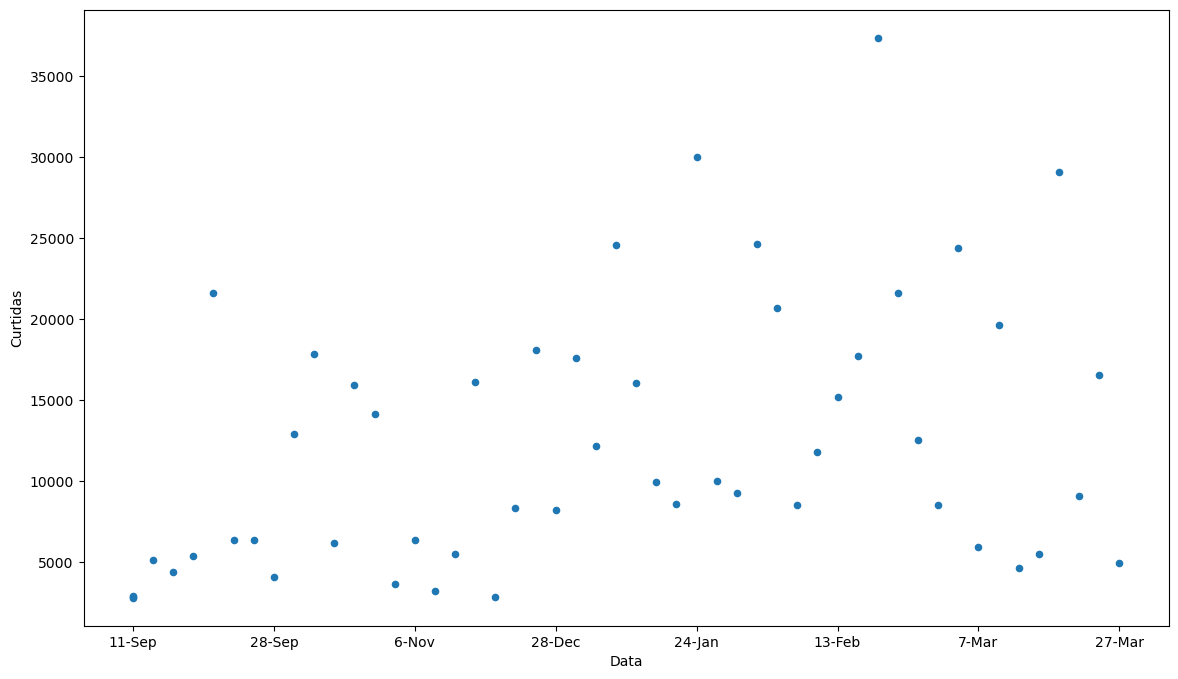

In [18]:
import matplotlib.pyplot as plt
# Um gráfico de dispersão ajudaria a entender melhor curtidas e comentários
# Plot
ax = base.plot(kind="scatter",x="Data",y="Curtidas",figsize=(14,8));
ax.set_xticks(new_dates)
plt.show()

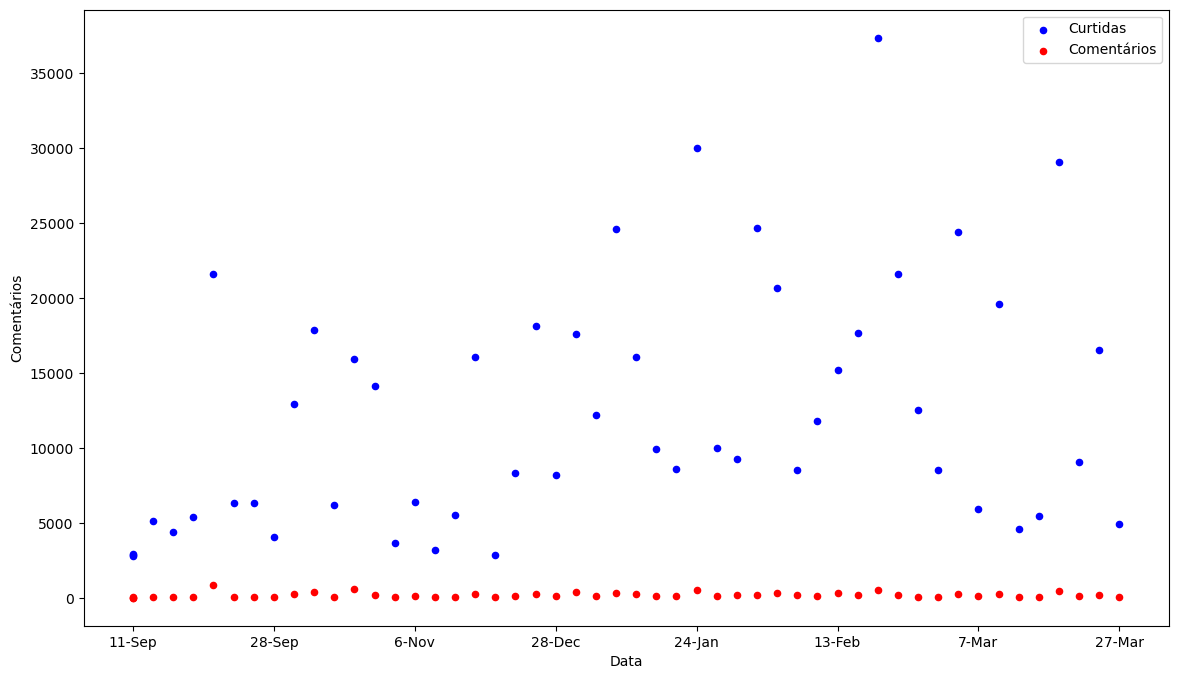

In [19]:
# Podemos colocar curtidas e comentários no mesmo gráfico
ax = base.plot(kind="scatter",x="Data",y="Curtidas",color="blue",label="Curtidas",figsize=(14,8));
base.plot(kind="scatter",x="Data",y="Comentários",color="red",label="Comentários",figsize=(14,8),ax=ax);
ax.set_xticks(new_dates)
plt.show()

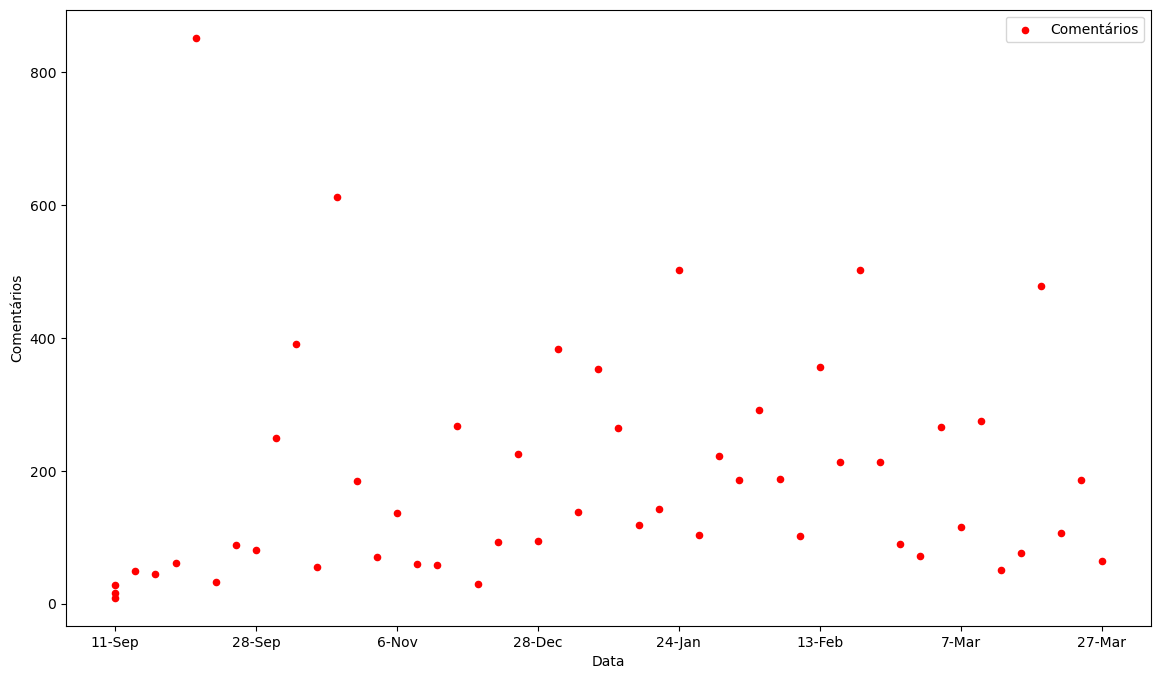

In [20]:
# A escala de curtidas pode estar atrapalhando a visualização, por isso vamos deixar comentários em um gráfico separado
ax = base.plot(kind="scatter",x="Data",y="Comentários",color="red",label="Comentários",figsize=(14,8));
ax.set_xticks(new_dates)
plt.show()

- O gráfico e as informações estatítiscas não estão dizendo muita coisa pois existe uma grande dispersão entre curtidas e comentários
- Precisamos verificar se existe um padrão usando as outras colunas de informações

### A primeira coisa que podemos fazer é pegar os 5 primeiros registros com mais e menos curtidas

In [21]:
# Ordenando os valores
base.sort_values(by="Curtidas",ascending=False).head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
39,Foto,17-Feb,37351.0,502,Promoções,S,S,N,37853.0
30,Reels,24-Jan,29981.0,502,Trends,S,S,N,30483.0
48,Foto,20-Mar,29084.0,479,Datas comemorativas/Promoções,S,S,N,29563.0
33,Foto,6-Feb,24655.0,186,Influenciadores,S,S,N,24841.0
26,Foto,8-Jan,24585.0,354,Datas comemorativas,S,S,S,24939.0


In [22]:
# Selecionando os 5 últimos valores 
base.sort_values(by="Curtidas",ascending=True).head()

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
2,Foto,11-Sep,2807.0,9,Loja,N,N,N,2816.0
0,Foto,11-Sep,2858.0,16,Loja,N,N,N,2874.0
20,Foto,16-Dec,2881.0,29,Produtos,N,N,N,2910.0
1,Foto,11-Sep,2930.0,28,Loja/Produtos,N,N,N,2958.0
17,Vídeo,9-Nov,3213.0,60,Produtos,N,N,N,3273.0


- Podemos observar que no top 5 todas as postagens tinham pessoas e eram fotos de campanha
- Nas 5 piores postagens, não haviam pessoas e nem eram postagens de campanhas
<br><br>
- **Isso pode ser um indicador que pessoas e campanhas tem relação com as curtidas**

### Vamos usar o <font color="blue">group by</font> para entender melhor os dados

**O group by é muito análogo a tabela dinâmica que fazemos no Excel**

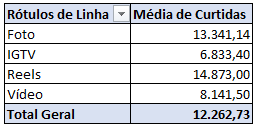

In [23]:
# Para melhorar a visualização, vamos criar um padrão no formato dos valores
pd.options.display.float_format = '{:,.2f}'.format

In [24]:
# Agrupando as informações por tipo
base.groupby("Tipo")["Comentários"].count()

Tipo
Foto     36
IGTV      5
Reels     5
Vídeo     6
Name: Comentários, dtype: int64

- **Nesse caso pode parecer que vídeo e IGTV são estratégias ruins que não devem ser usadas**

**O groupby nos permite agregar os dados, o que facilita muito a visualização** <br>
base.<font color="blue">**groupby**</font>("<font color="red">**coluna1**</font>")["<font color="green">**coluna2**</font>"].<font color="purple">**funcao_agregacao()**</font>

- O groupby vai agregar pela <font color="red">**coluna1**</font>
- A <font color="purple">**função de agregação**</font> será aplicada na <font color="green">**coluna2**</font>

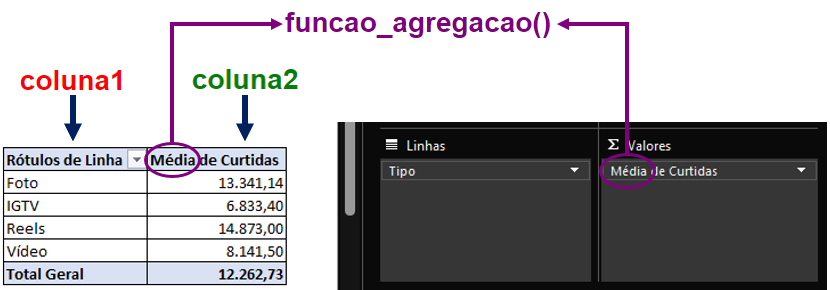

**Inclusive é possível agregar por mais de 1 coluna:** <br>

In [25]:
# Agrupando por Tipo e Pessoas
base.groupby(["Tipo","Pessoas"])["Curtidas"].mean()

Tipo   Pessoas
Foto   N          3,863.50
       S         15,236.67
IGTV   S          6,833.40
Reels  N          5,934.50
       S         20,832.00
Vídeo  N          4,007.50
       S         16,409.50
Name: Curtidas, dtype: float64

**E também aplicar a função de agregação em várias outras colunas:** <br>

In [26]:
base.groupby(["Tipo","Pessoas"])[["Curtidas",'Comentários']].mean()

Curtidas  Comentários
Tipo  Pessoas                       
Foto  N        3,863.50        29.50
      S       15,236.67       226.20
IGTV  S        6,833.40       133.60
Reels N        5,934.50        98.00
      S       20,832.00       342.00
Vídeo N        4,007.50        65.25
      S       16,409.50       370.00

In [27]:
# Incluindo a coluna de campanhas
base.groupby(["Tipo","Pessoas", "Campanhas"])[["Curtidas",'Comentários']].mean()

Curtidas  Comentários
Tipo  Pessoas Campanhas                       
Foto  N       N          2,869.00        20.50
              S          5,852.50        47.50
      S       N         10,815.29       159.93
              S         19,105.38       284.19
IGTV  S       N          6,833.40       133.60
Reels N       N          5,934.50        98.00
      S       N         12,894.00       249.00
              S         24,801.00       388.50
Vídeo N       N          4,007.50        65.25
      S       S         16,409.50       370.00

- O groupby já permite ver que publicações de campanha tem um grande engajamento e com foto de pessoas também

**Podemos então fazer os agrupamentos que acharmos melhor para entender os nossos dados**

In [28]:
# Somente para pessoas
base.groupby(["Pessoas"])[["Curtidas",'Comentários']].mean()

,Curtidas,Comentários
Pessoas,,
N,"4,256.67",52.83
S,"14,664.55",230.50


- **Postagens com pessoas engajam muito mais para essa marca, sendo 3 vezes maior de quando não tem pessoas**

In [29]:
# Somente para campanhas
base.groupby(["Campanhas"])[["Curtidas",'Comentários']].mean()

,Curtidas,Comentários
Campanhas,,
N,"7,928.33",123.17
S,"18,173.27",279.95


- **Quando é uma postagem de campanha, o engajamento também é melhor!**

In [ ]:
# Carrossel (sem filtrar a base) > ESTÁ ERRADA ESSA COMPARAÇÃO
base.groupby(["Carrossel"])[["Curtidas",'Comentários']].mean()

,Curtidas,Comentários
Carrossel,,
N,"12,343.61",198.43
S,"11,817.88",140.38


In [31]:
# Podemos também filtrar a base
base[base.Tipo == 'Foto'].groupby(["Carrossel"])[["Curtidas",'Comentários']].mean()

,Curtidas,Comentários
Carrossel,,
N,"13,776.36",208.57
S,"11,817.88",140.38


- **A média sem usar carrossel é melhor do que quando usamos, então não é algo que possa impactar tanto no resultado das mídias dessa empresa olhando inicialmente**
    - Nesse caso devemos filtrar apenas as fotos pois só temos carrossel em fotos. Sem esse filtro estaríamos comparando coisas erradas

**Colocando pessoas e campanhas juntos podemos ver como se dá essa diferença**

In [32]:
# Agregando por pessoas e campanhas
base.groupby(["Pessoas", "Campanhas"])[["Curtidas",'Comentários']].mean()

Curtidas  Comentários
Pessoas Campanhas                       
N       N          3,937.50        53.90
        S          5,852.50        47.50
S       N          9,923.75       157.80
        S         19,405.35       303.20

- **A média quando tem pessoas E é publicação de campanhas é de cerca de 19,4 mil curtidas, já quando é apenas pessoas (sem campanha passa para quase 10 mil e se não tiver pessoas chega no máximo a 5,9 mil mesmo em campanhas**
<br><br>
- **Nesse caso a gente já consegue mostrar para a empresa a importância de incluir pessoas usando os seus produtos, o que gera um aumento considerável no engajamento**

In [34]:
# Agregando por pessoas, campanhas e tipo
base.groupby(["Pessoas", "Campanhas", "Tipo"])[["Curtidas",'Comentários']].mean()

Curtidas  Comentários
Pessoas Campanhas Tipo                        
N       N         Foto   2,869.00        20.50
                  Reels  5,934.50        98.00
                  Vídeo  4,007.50        65.25
        S         Foto   5,852.50        47.50
S       N         Foto  10,815.29       159.93
                  IGTV   6,833.40       133.60
                  Reels 12,894.00       249.00
        S         Foto  19,105.38       284.19
                  Reels 24,801.00       388.50
                  Vídeo 16,409.50       370.00

- **Analisando novamente a questão do vídeo, ele não parece mais tão ruim assim. Quando feito em campanha e usando pessoas ele teve um resultado bom, inclusive próximo a foto**
- O que poderia ter levado a média baixa é que só temos vídeo ou COM pessoa e COM campanha ou sem nenhum dos dois. Não temos nenhum vídeo com apenas um dos dois (pessoa ou campanha)
- Já IGTV, mesmo tendo pessoa, não teve um resultado tão bom

#### Inclusive podemos entender o que havia gerado a média baixo no vídeo

In [35]:
# Vamos filtrar a base apenas onde o tipo é Vídeo
base[base.Tipo == 'Vídeo']

,Tipo,Data,Curtidas,Comentários,Tags,Pessoas,Campanhas,Carrossel,Interacoes
3,Vídeo,12-Sep,"5,115.00",49,Produtos,N,N,N,"5,164.00"
9,Vídeo,28-Sep,"4,056.00",81,Produtos,N,N,N,"4,137.00"
15,Vídeo,4-Nov,"3,646.00",71,Produtos,N,N,N,"3,717.00"
17,Vídeo,9-Nov,"3,213.00",60,Produtos,N,N,N,"3,273.00"
24,Vídeo,30-Dec,"17,600.00",383,Trends,S,S,N,"17,983.00"
37,Vídeo,13-Feb,"15,219.00",357,Datas comemorativas,S,S,N,"15,576.00"


- **Aqui percebemos que a loja tentou postar 4 vídeos mostrando seus produtos (sem nenhuma pessoa) e o resultado foi baixo. Quando o vídeo foi feito com pessoas aproveitando trends e datas comemorativas o resultado foi muito bom!**

## Conclusões
- **Em uma análise inicial, postagens incluindo pessoas engajam muito mais que aquelas que não possui ninguém**
- **Postagens em épocas de campanha também possuem um melhor engajamento**
- **Nessa base, o carrossel não foi um diferencial para melhorar o engajamento da marca**